Let's start by defining our paths and importing everything we will need to visualize and fit our events...

In [1]:
wcsim_data_dir = '/eos/experiment/wcte/wcte_tests/mPMT_led_events/LicketyFit_stuff/tutorial/wcsim_data/'
lf_base_dir = '../'
geo_path = lf_base_dir + 'Geometry/'
scripts_path = lf_base_dir + 'scripts/'

import sys
sys.path.insert(0, geo_path)
sys.path.insert(0, scripts_path)


import numpy as np
import time
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import os
import uproot, json, awkward as ak
from Geometry.Device import Device
from pathlib import Path
import sys
import importlib.util
from particle_range_lookup import *
from display_3D_event import *
from single_event_fit import (
    WCTEConfig,
    WCSimConfig,
    SingleEventFitter,
    runtime_cache_report,
    summarize_fit,
    truth_residuals,
    wcsim_npz_primary_truth,
)
from plot_event import plot_event



We'll start by fitting WCSim events, since this also gives us a chance to visualize our events in 3D before we fit them! For this, we'll use a 3D event display plotter located in the /tools directory, and WCSim data located in the /wcsim_data directory. This data was generated so that every particle step and every photon history is saved, giving us the ability to actually see the interesting physics at play! I would suggest looking in the mu- folder first, and then moving to more exotic particles.

In [2]:
# There are mu-, pi-, pi+, proton, e+, and gamma directories
particle = 'pi+'
wcsim_data_path = wcsim_data_dir + particle + '/'

# Have a look in the 
# /eos/experiment/wcte/wcte_tests/mPMT_led_events/LicketyFit_stuff/tutorial/wcsim_data/<particle> 
# directory and choose which file you would like to look at:

os.listdir(wcsim_data_path)

['100pi+_200MeV_bp.npz',
 '100pi+_200MeV_bp.root',
 '100pi+_300MeV_bp.npz',
 '100pi+_300MeV_bp.root',
 '100pi+_400MeV_bp.npz',
 '100pi+_400MeV_bp.root']

In [19]:
base_filename = wcsim_data_path + '100pi+_400MeV_bp'

root_file = base_filename+'.root'
npz_file = base_filename+'.npz'

We need to extract the relevant data from the wcsim root file. That's what the following code does...

In [20]:
# Define the TTrees we want to read in. We'll only read in pieces of them because they are very large!

n = 1000000   # number of entries to load, this is NOT the number of events
all_sec = "AllSecondaries"
all_sec_ph = "AllSecondaryPhotons"

# Read in the TTrees and convert them to a nice pandas dataframe

with uproot.open(root_file) as f:


    t_sec = f[all_sec]
    arr_sec = t_sec.arrays(library="ak", entry_stop=n)
    
    t_sec_ph = f[all_sec_ph]
    arr_sec_ph = t_sec_ph.arrays(library="ak", entry_stop=n)


df_sec = ak.to_dataframe(arr_sec).reset_index(drop=True)
df_sec_ph = ak.to_dataframe(arr_sec_ph).reset_index(drop=True)

df_sec is a pandas dataframe that contains information on every step that each particle makes in an event, while df_sec_ph contains information information on each Cherenkov photon that is created (including its wavelength, its parent particle, which PMT it made a PE in etc.)

In [21]:
# Check out the data per-step particle data
df_sec.keys()

Index(['evt', 'trk', 'parent', 'pdg', 'step', 'x_cm', 'y_cm', 'z_cm', 't_ns',
       'post_x_cm', 'post_y_cm', 'post_z_cm', 'post_t_ns', 'dir_x', 'dir_y',
       'dir_z', 'post_dir_x', 'post_dir_y', 'post_dir_z', 'ke_MeV',
       'post_ke_MeV', 'edep_MeV', 'step_length_cm', 'track_length_cm',
       'charge', 'particle', 'creator', 'step_process', 'volume',
       'post_volume', 'material', 'post_material'],
      dtype='object')

In [22]:
# We can apply a mask to only look at columns/rows that we're interested in.
# For example, let's look at the steps from the primary particle in event 0.
# In WCSim, the primary particle always has track=1

mask = (df_sec['evt']==0) & (df_sec['trk']==1)

df_sec[mask]

,evt,trk,parent,pdg,step,x_cm,y_cm,z_cm,t_ns,post_x_cm,...,step_length_cm,track_length_cm,charge,particle,creator,step_process,volume,post_volume,material,post_material
0,0,1,0,211,1,0.000000,-42.476299,-134.800003,0.000000,0.000000,...,0.138486,0.138486,1.0,pi+,NONE,Cerenkov,WCBarrelAnnulus,WCBarrelAnnulus,Water,Water
1,0,1,0,211,2,0.000000,-42.476299,-134.661514,0.004782,-0.000008,...,0.138509,0.276994,1.0,pi+,NONE,Cerenkov,WCBarrelAnnulus,WCBarrelAnnulus,Water,Water
2,0,1,0,211,3,-0.000008,-42.475986,-134.523010,0.009565,-0.000120,...,0.138519,0.415514,1.0,pi+,NONE,Cerenkov,WCBarrelAnnulus,WCBarrelAnnulus,Water,Water
3,0,1,0,211,4,-0.000120,-42.475624,-134.384491,0.014349,0.000129,...,0.138530,0.554044,1.0,pi+,NONE,Cerenkov,WCBarrelAnnulus,WCBarrelAnnulus,Water,Water
4,0,1,0,211,5,0.000129,-42.475338,-134.245956,0.019134,0.000118,...,0.138544,0.692588,1.0,pi+,NONE,Cerenkov,WCBarrelAnnulus,WCBarrelAnnulus,Water,Water
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,0,1,0,211,398,11.085579,-58.091061,-84.934448,1.990390,11.142545,...,0.153883,56.921486,1.0,pi+,NONE,Cerenkov,WCBarrel,WCBarrel,Water,Water
527,0,1,0,211,399,11.142545,-58.169949,-84.815239,1.995894,11.199364,...,0.153947,57.075432,1.0,pi+,NONE,Cerenkov,WCBarrel,WCBarrel,Water,Water
528,0,1,0,211,400,11.199364,-58.248989,-84.695976,2.001402,11.256702,...,0.153997,57.229427,1.0,pi+,NONE,Cerenkov,WCBarrel,WCBarrel,Water,Water
529,0,1,0,211,401,11.256702,-58.327881,-84.576797,2.006911,11.314174,...,0.154056,57.383484,1.0,pi+,NONE,Cerenkov,WCBarrel,WCBarrel,Water,Water


In [23]:
# Check out the data per-photon data
df_sec_ph.keys()

Index(['evt', 'trk', 'parent', 'parent_pdg', 'parent_parent', 'parent_step',
       'pdg', 'parent_ke_MeV', 'sx_cm', 'sy_cm', 'sz_cm', 'st_ns', 'dir_x',
       'dir_y', 'dir_z', 'lambda_nm', 'hit_pmt', 'hit_x_cm', 'hit_y_cm',
       'hit_z_cm', 'hit_t_ns', 'made_pe', 'pe_pmt', 'pe_time_ns',
       'pe_lambda_nm', 'end_x_cm', 'end_y_cm', 'end_z_cm', 'end_t_ns',
       'end_status', 'creator', 'parent_creator', 'hit_volume', 'end_boundary',
       'end_process'],
      dtype='object')

In [24]:
# Let's look at some of the photons produced in the first event by the primary particle

mask_ph = (df_sec_ph['evt']==0) & (df_sec_ph['parent']==1)

df_sec_ph[mask_ph]

,evt,trk,parent,parent_pdg,parent_parent,parent_step,pdg,parent_ke_MeV,sx_cm,sy_cm,...,end_x_cm,end_y_cm,end_z_cm,end_t_ns,end_status,creator,parent_creator,hit_volume,end_boundary,end_process
0,0,2,1,211,0,1,0,400.000000,0.000000,-42.476299,...,5.993255,13.915304,-64.812263,4.060904,2,Cerenkov,NONE,,WCBarrel,OpAbsorption
1,0,3,1,211,0,1,0,400.000000,0.000000,-42.476299,...,-42.592133,-109.372803,-150.563812,7.784204,2,Cerenkov,NONE,pmt,NuPRISMBeamTest_16cShort_mPMT-glassFaceWCPMT,OpAbsorption
2,0,4,1,211,0,1,0,400.000000,0.000000,-42.476299,...,-148.546478,-0.479669,45.347160,11.506113,2,Cerenkov,NONE,,physMatrix,Transportation
3,0,5,1,211,0,1,0,400.000000,0.000000,-42.476299,...,-131.242416,-135.886429,46.263664,12.674545,2,Cerenkov,NONE,pmt,NuPRISMBeamTest_16cShort_mPMT-glassFaceWCPMT,OpAbsorption
4,0,6,1,211,0,1,0,400.000000,0.000000,-42.476299,...,11.124743,135.711746,84.911644,12.786448,2,Cerenkov,NONE,,WCBotCapBlackSheet,Transportation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40233,0,40261,1,211,0,401,0,246.109604,11.278972,-58.358681,...,153.796295,-54.741169,24.207169,12.273787,2,Cerenkov,NONE,,WCBarrelAnnulusBlackSheet,Transportation
40234,0,40262,1,211,0,401,0,246.109604,11.277631,-58.356827,...,-134.858856,5.999956,-71.845657,13.810187,2,Cerenkov,NONE,pmt,NuPRISMBeamTest_16cShort_mPMT-glassFaceWCPMT,OpAbsorption
40235,0,40263,1,211,0,401,0,246.109604,11.300170,-58.387997,...,138.150009,-49.015717,54.559151,10.842189,2,Cerenkov,NONE,pmt,InteriorWCPMT,Transportation
40236,0,40264,1,211,0,401,0,246.109604,11.312414,-58.404930,...,150.626144,-100.369057,-12.680095,9.676986,2,Cerenkov,NONE,pmt,InteriorWCPMT,Transportation


Let's now plot our event. Choose your event number, and customize what you would actually like to see in the event. For example, if you only want to see high energy particles, place your min_creation_ke_MeV cut at something like 10 MeV. Once you've plotted the event, hover over any of the PMTs, particles, or processes to get more information. For example, hovering over a hit PMT will tell you how many PEs were made and which particles they were made by. The legend is also interactive and allows you to isolate any of the particles/interactions that you're interested in. When you're done, try plotting a different particle!  

The code in the cell below is meant to show the 3D event display, but the current network connection/browser may prevent it from appear. In that case, run the cell below it and click on the link that is printed.

In [25]:
event_number = 1 # Choose the event number you would like to display


# Here, we hand the plotter our two dataframes and customize what we actually want to plot
display3d = WCTEEventDisplay(
    df_sec,
    df_sec_ph,
    geometry_parent=geo_path,  # folder containing Geometry/ or the geometry .py files
)
# Default behaviour:
#   - track steps shown only for t_ns < 20
#   - PMT PE colouring uses the same 20 ns cut on pe_time_ns
#   - only tracks with creation KE >= 0.2 MeV are shown
#   - electrons are shown
#   - all PMTs are shown, with unhit ones grey
#   - mPMT slot numbers are shown
fig, summary, chosen, pmt_pe_df = display3d.plot_event(
    event_id=event_number,
    min_creation_ke_MeV=0.2,
    min_track_length_mm=None,
    time_cut_ns=20,
    show_terminal_process_markers=False, # Set this to True in order to see all interactions labelled on plot
    show_terminal_process_labels=False,   # marker only, no text in 3D
    terminal_process_in_track_legend=True, # Set this to True in order to see all interactions labelled in legend
)

fig.show()

Run the cell below if your event display did not appear. Click the link after the cell runs.

In [26]:
from IPython.display import display, FileLink

filename = f"wcsim_event_{event_number}.html"

fig.write_html(
    filename,
    include_plotlyjs=True,
    full_html=True,
    auto_open=False,
)

display(FileLink(filename))

/eos/home-i01/j/jrimmer/SWAN_projects/beam/LicketyFit_official/examples/wcsim_event_1.html

# Fitting WCSim Data

Okay, let's now try fitting this event with LicketyFit! Note that LicketyFit does not currently have the ability to fit electrons/positrons or gammas, so if you've chosen one of these particles you'll need to change it. 

Let's start by using the configuration settings you'll actually use in run_wcsim.py.

In [11]:
wcsim_config = WCSimConfig(
    input_file=str(npz_file),
    fit_particle='muon',
    seeding_mode='general',           # 'general' (detector-wide) or 'beam'
    interaction_mode='absorption',   # 'full_length' or 'absorption'
    likelihood_mode='charge_time',    # 'charge_only', 'charge_time', 'timing_only'
    n_events=1,
    event_start_index=event_number,
    fixed_parameters = {},
    use_absolute_light_yield=False,
)
wcsim_config

WCSimConfig(input_file='/eos/experiment/wcte/wcte_tests/mPMT_led_events/LicketyFit_stuff/tutorial/wcsim_data/pi+/100pi+_300MeV_bp.npz', interaction_mode='absorption', n_events=1, event_start_index=1, use_absolute_light_yield=False)

Let's now load in the event and have a quick look at it...

In [12]:
wcsim_fitter = SingleEventFitter(wcsim_config)
wcsim_events = wcsim_fitter.load_events()

pd.DataFrame([
    {
        'input_index': event.source_index,
        'digitized_hits': event.n_hits,
        'total_charge_pe': event.total_charge,
    }
    for event in wcsim_events
])

,input_index,digitized_hits,total_charge_pe
0,1,339,733.960493


We now need to get set up LicketyFit so that it's ready for when we pass it our data. This is a one-time warm-up cost. It may take 1-2 minutes...

In [13]:
print('Building geometry, tables, seeds, proxy library and compiled kernels.')
print('This is one-time setup, NOT the fit. On a fresh account: a few minutes.')

setup_start = time.perf_counter()
wcsim_fitter.initialize()
wcsim_setup_wall = time.perf_counter() - setup_start

print(f'\nfitter setup finished in {wcsim_setup_wall:.1f} s')

Building geometry, tables, seeds, proxy library and compiled kernels.
This is one-time setup, NOT the fit. On a fresh account: a few minutes.

fitter setup finished in 72.6 s


Even though we already say the 3D event display, it can still be useful to have a look at the 2D charge and time maps. This following plots use the exact time cut that LicketyFit will use, so you get to see the exact input the fitter sees.

PreparedEvent(source='wcsim', source_index=1, hit_pmts=248/1843, total_pe=631.766, prompt_window_ns=(0, 16))
prompt window: 0.0 to 16.0 ns
hits:          339 digitized -> 248 active PMTs with prompt charge


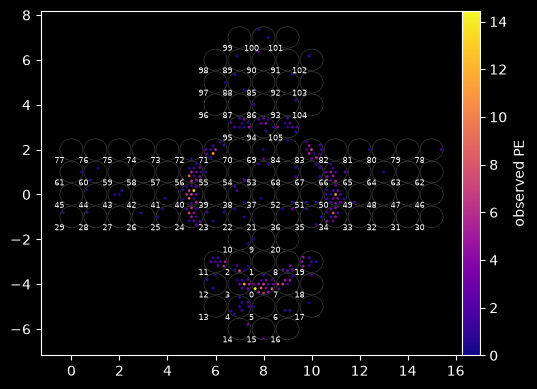

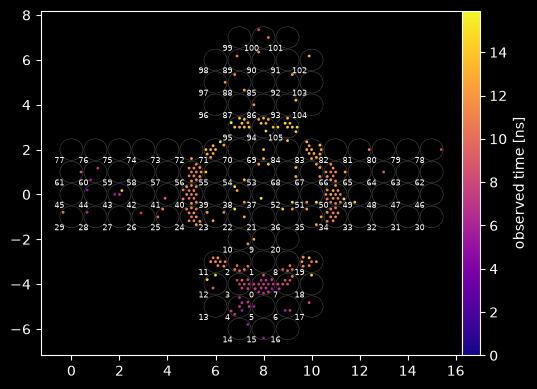

In [14]:
wcsim_event = wcsim_events[0]
wcsim_prepared = wcsim_fitter.prepare_event(wcsim_event)

print(wcsim_prepared)
print(f'prompt window: {wcsim_prepared.prompt_min_ns:.1f} to '
      f'{wcsim_prepared.prompt_max_ns:.1f} ns')
print(f'hits:          {wcsim_event.n_hits} digitized -> '
      f'{wcsim_prepared.n_hit_pmts} active PMTs with prompt charge')

plot_event(wcsim_prepared, quantity='observed_pe')
plot_event(wcsim_prepared, quantity='observed_time');

It's time to do the fit itself! Unfortunately the first fit may take ~1 minute, as there is still a further warm-up period.

In [16]:
fit_start = time.perf_counter()
wcsim_result = wcsim_fitter.fit(wcsim_event)
print(f'fit: {time.perf_counter() - fit_start:.1f} s '
      f'(setup was {wcsim_setup_wall:.1f} s and is not repeated)')

summarize_fit(wcsim_result)

fit: 2.1 s (setup was 72.6 s and is not repeated)


,value
minimum_valid,True
fit_accepted,True
objective_finite,True
fval,610.683428
mcs_status,applied
mcs_applied,True
straight_fit_fval,610.683428
optimizer,track_aligned_exact_joint_block_quadratic
total_objective_evaluations,311
fit_attempts,3


,estimate,error
parameter,,
x0,-28.739738,10.726010
y0,-50.138610,12.831166
z0,-1258.362407,6.637038
cx,0.020744,0.003754
cy,0.006034,0.005172
cz,0.999767,0.000084
length,394.594160,19.016044
visible_length,394.594160,19.016044
full_range,1170.924640,27.449380


minimum_valid                                                         True
fit_accepted                                                          True
objective_finite                                                      True
fval                                                            610.683428
mcs_status                                                         applied
mcs_applied                                                           True
straight_fit_fval                                               610.683428
optimizer                        track_aligned_exact_joint_block_quadratic
total_objective_evaluations                                            311
fit_attempts                                                             3
optimized_basins                                                         3
seed_candidates_retained                                                18
candidate_failures                                                       0
optimizer_history_records

Try plotting the event again, alongside the LicketyFit charge distribution prediction. Remember: all the fitter does is produce a set of track parameters, produce the resulting charge/time distribution, and check how it compares with the actual event.

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(wcsim_result.observed_pe, wcsim_result.expected_pe, s=8, alpha=0.7)
limit = max(wcsim_result.observed_pe.max(), wcsim_result.expected_pe.max(), 1.0)
axes[0].plot([0, limit], [0, limit], 'k--', linewidth=1)
axes[0].set(xlabel='observed PE after cuts', ylabel='expected PE at estimate')
timed = wcsim_result.timing_comparison_mask
axes[1].scatter(
    wcsim_result.expected_time_ns[timed],
    wcsim_result.observed_time_ns[timed],
    s=8, alpha=0.7,
)
axes[1].set(xlabel='model first-arrival mean [ns]', ylabel='observed time [ns]')
fig.tight_layout()

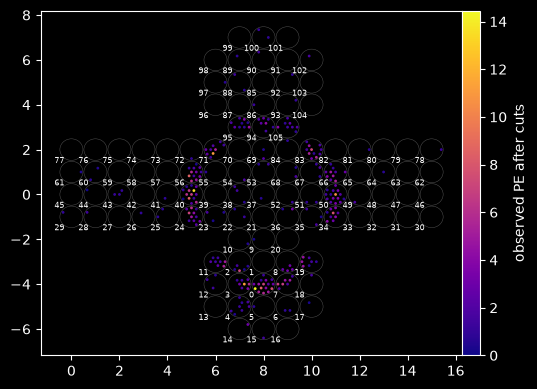

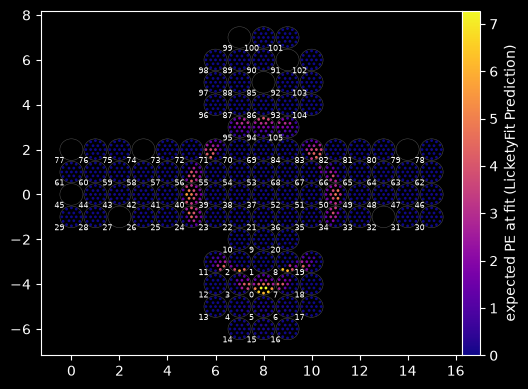

In [18]:
plot_event(wcsim_result, quantity='observed_pe', color_label='observed PE after cuts')
plot_event(wcsim_result, quantity='expected_pe', color_label='expected PE at fit (LicketyFit Prediction)');

Before you continue onto fitting real data, try fitting another particle: if your previous fit was done in full_length mode, try fitting a pion/proton absorption event (in absorption mode) - this will require looking through some events and identifying ones that are absorption-like (hint: WCSim simply labels absorption interactions as "Inelastic"). If you can't find an absorption event, check out event 1 in 100pi+_300MeV_bp.root

# WCSim Fitting Questions

1) Check the estimated fitted length for your event and compare it to the true length (hover over the particle track in the 3D event display to get the length). Are they close to one another? If not, why might this be? Hint: the answer will be different depending upon whether you used full_length or absorption mode.

2) In absorption mode, the default fitter attempts to fit 8 parameters. What are they? When fitting pion/proton events in absorption mode, why might fixing the known parameters (like vertex and kinetic energy) help when it comes to fitting the length?

3) Muons, pions, and protons all can produce delta rays (secondary electrons) as they travel through water. Let's assume that for a single event, most of the Cherenkov light produced from those delta rays is in the same direction as the primary particle. What effect might this have on the length estimate given by LicketyFit?  

# Fitting Real WCTE Data

We can now start fitting real WCTE data. Most of the configuration settings are the same/similar to the WCSim fits, except for a few additions:

- You must define a run which you would like to look at (check the run spreadsheet if you're unsure):

https://docs.google.com/spreadsheets/d/1glxaM1DL0I5c9In96sTuTdeQqxhN6M5yowyEj19FO8w/edit?pli=1&gid=1182887701#gid=1182887701

If you're looking at muons/pions, I suggest run 2079.

- You can either let the code perform the selection for you (this is event_source='selection' mode), or you can provide a file that contains the individual PMT hits that you would like to fit (using event_source='file'). For today, use the default 'selection' setting.

- In addition to defining the particle that LicketyFit assumes you are fitting, you must define the particle that the dataloader will select for (particle_selection_label='*particle*'). These will generally be the same, but the two definitions are separate for now.

- You must define the kind of beam line cuts to use. Generally, you should use both ACT and TOF: light_particle_pid_mode='act_tof'.

- The code does not know beforehand which of the root file entries will pass the beamline selection criteria, so you must define the number of entries to search through: n_root_entries=1000

In [58]:
wcte_config = WCTEConfig(
    run=2079,
    event_source='selection',
    good_pmt_source='run',
    particle_selection_label='muon',   # which beam population to select
    fit_particle='muon',               # which track hypothesis to fit
    seeding_mode='general',            # 'general' (detector-wide) or 'beam'
    interaction_mode='full_length',     # 'full_length' or 'absorption'
    likelihood_mode='charge_time',     # 'charge_only', 'charge_time', 'timing_only'
    light_particle_pid_mode='act_tof', # 'act_tof' (default), 'tof', or 'act'
    n_root_entries=1000,               # This is how many possible selection events are read from the root file
    max_events_to_fit=10,
)
wcte_config

WCTEConfig(n_root_entries=1000, max_events_to_fit=10, good_pmt_source='run')

Okay, we have our configuration settings, so now let's load in our events...

In [59]:
wcte_fitter = SingleEventFitter(wcte_config)
wcte_events = wcte_fitter.load_events()
wcte_events

EventCollection(source='wcte', n_events=10)

Let's have a quick look at the events we have loaded...

In [60]:
# Just look at a few metrics, like the number of hits and the summed ADC charge

pd.DataFrame([
    {
        'selected_index': i,
        'root_entry': event.metadata.get('source_root_entry_index'),
        'event_id': event.metadata.get('source_event_id'),
        'raw_hits': event.n_hits,
        'raw_charge_adc': event.total_charge,
    }
    for i, event in enumerate(wcte_events)
])

,selected_index,root_entry,event_id,raw_hits,raw_charge_adc
0,0,32,32,7909,2903486.0
1,1,39,39,2757,1082461.0
2,2,53,53,6679,2541200.0
3,3,96,96,6793,2392032.0
4,4,102,102,4762,1681858.0
5,5,186,186,10034,4072195.0
6,6,187,187,5845,2188724.0
7,7,189,189,5839,2259077.0
8,8,208,208,6325,2250944.0
9,9,214,214,9067,3529036.0


We can also check out the full set of beam selection cuts that were used to select these events

In [61]:
# Check beam selection cuts

summary = wcte_fitter.selection_summary()
display(pd.Series(
    {k: v for k, v in summary.items() if k != 'selection_cut_specs'},
    name='value',
).to_frame())

print('Cuts applied by BeamSelection:')
for branch, operator, value in summary['selection_cut_specs']:
    print(f'  {branch} {operator} {value}')

,value
run,2079
event_source,selection
particle_selection_label,muon
selection_mode,nominal
light_particle_pid_mode,act_tof
light_particle_pid_mode_applied,act_tof
act_fallback_used,False
unavailable_tof_boundaries,[]
events_returned,10
selected_before_hit_time_cut,10


Cuts applied by BeamSelection:
  vme_act_eveto < 4.522613065326634
  vme_act_tagger > 13.333333333333332
  vme_tof_corr between [14.86063975127714, 15.265457291289913]


Now it's time to fit the event(s)! First ensure the fitter is warmed and ready...

In [62]:
print('One-time setup for the WCTE fitter. This is NOT the fit.')

setup_start = time.perf_counter()
wcte_fitter.initialize()
wcte_setup_wall = time.perf_counter() - setup_start

print(f'\nfitter setup finished in {wcte_setup_wall:.1f} s')
print('Every event fitted with this fitter now reuses it.')

One-time setup for the WCTE fitter. This is NOT the fit.

fitter setup finished in 7.4 s
Every event fitted with this fitter now reuses it.


Now select the event number you want within your sample and perform the fit!

PreparedEvent(source='wcte', source_index=9, hit_pmts=460/1579, total_pe=1219.66, prompt_window_ns=(-8.75, 16.2))
prompt window:      -8.75 to 16.25 ns, in the event-relative reference
time offset removed: 2185.75 ns
hits:                9067 loaded -> 460 inside the prompt window and on an active PMT


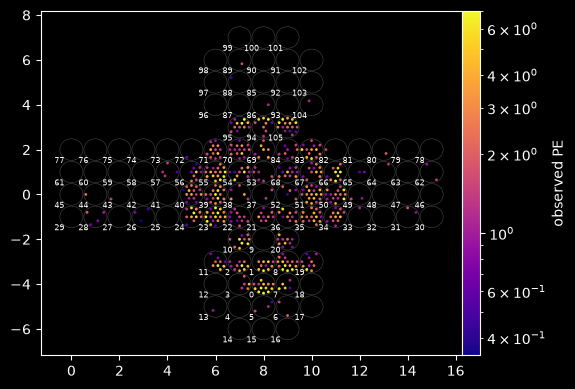

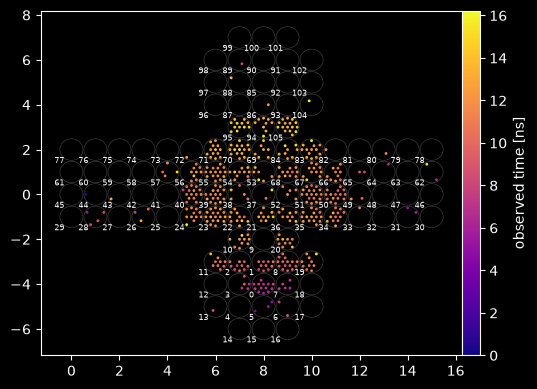

In [79]:
WCTE_EVENT_INDEX = 9
wcte_event = wcte_events[WCTE_EVENT_INDEX]
wcte_prepared = wcte_fitter.prepare_event(wcte_event)

meta = wcte_prepared.metadata
print(wcte_prepared)
print(f"prompt window:      {wcte_prepared.prompt_min_ns:.2f} to "
      f"{wcte_prepared.prompt_max_ns:.2f} ns, in the event-relative reference")
print(f"time offset removed: {meta.get('global_time_offset_ns', float('nan')):.2f} ns")
print(f"hits:                {meta.get('raw_hit_count')} loaded -> "
      f"{meta.get('prompt_hit_count')} inside the prompt window and on an active PMT")

plot_event(wcte_prepared, quantity='observed_pe', log_scale=True,vmax=7)
plot_event(wcte_prepared, quantity='observed_time');

In [80]:
fit_start = time.perf_counter()
wcte_result = wcte_fitter.fit(wcte_event)
print(f'fit: {time.perf_counter() - fit_start:.1f} s '
      f'(setup was {wcte_setup_wall:.1f} s and is not repeated)')

summarize_fit(wcte_result)

fit: 7.4 s (setup was 7.4 s and is not repeated)


,value
minimum_valid,True
fit_accepted,True
objective_finite,True
fval,905.069944
mcs_status,applied
mcs_applied,False
straight_fit_fval,1020.539271
optimizer,track_aligned_exact_joint_block_quadratic
total_objective_evaluations,698
fit_attempts,3


,estimate,error
parameter,,
x0,-58.278418,11.588807
y0,29.477752,30.595534
z0,-1347.396568,6.313936
cx,-0.003992,0.004296
cy,-0.015784,0.014280
cz,0.999867,0.000538
length,1322.269581,NaN
visible_length,1322.269581,NaN
full_range,1322.269581,38.712587


minimum_valid                                                         True
fit_accepted                                                          True
objective_finite                                                      True
fval                                                            905.069944
mcs_status                                                         applied
mcs_applied                                                          False
straight_fit_fval                                              1020.539271
optimizer                        track_aligned_exact_joint_block_quadratic
total_objective_evaluations                                            698
fit_attempts                                                             3
optimized_basins                                                         3
seed_candidates_retained                                                 4
candidate_failures                                                       0
optimizer_history_records

As before, let's have a look at the LicketyFit prediction alongside the true event

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(wcte_result.observed_pe, wcte_result.expected_pe, s=8, alpha=0.7)
limit = max(wcte_result.observed_pe.max(), wcte_result.expected_pe.max(), 1.0)
axes[0].plot([0, limit], [0, limit], 'k--', linewidth=1)
axes[0].set(xlabel='observed PE after cuts', ylabel='expected PE at estimate')
timed = wcte_result.timing_comparison_mask
axes[1].scatter(
    wcte_result.expected_time_ns[timed],
    wcte_result.observed_time_ns[timed],
    s=8, alpha=0.7,
)
axes[1].set(xlabel='expected time [ns]', ylabel='observed time [ns]')
fig.tight_layout()

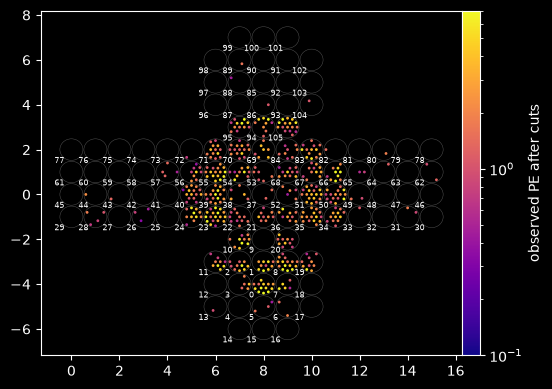

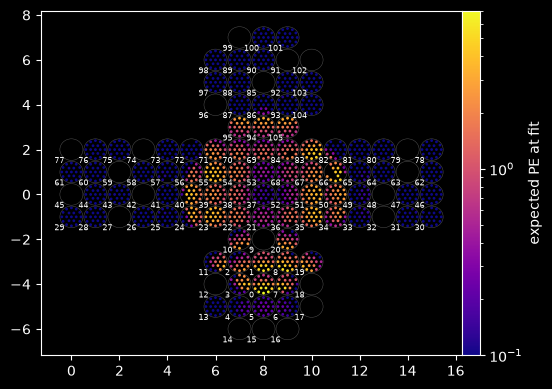

In [82]:
vmin = 0.1
vmax = 7
plot_event(wcte_result, quantity='observed_pe', color_label='observed PE after cuts', log_scale=True, vmin=vmin, vmax=vmax)
plot_event(wcte_result, quantity='expected_pe', color_label='expected PE at fit', log_scale=True, vmin=vmin, vmax=vmax);

# WCTE Fitting Questions

1) Let's say we're wanting to select and fit a muon sample from WCTE beam data. Unfortunately, a sneaky pion has passed the muon selection cuts and has entered our sample without us knowing. You run the fitter on your sample and find clues that your sample is contaminated. 

    a) What might these clues be?

    b) Beyond just the fitter output itself, how could you gather more evidence that your sample is contaminated?
    
    c) The event display for the sneaky pion event clearly contains two rings. You strongly suspect it is a pion.          Should you just add it to your pion sample and fit it using LicketyFit's absorption mode?